In [1]:
#package
import requests
import zipfile
import sqlite3
import pandas as pd
import numpy as np


Vous avez accès à la base de données d'une boutique de musique en ligne.

Ci dessous les differentes tables de cette base:

In [2]:
# Executer ce code permettant de créer une connexion avec la base de données


# Obtenez le lien du fichier ZIP brut depuis GitHub
github_url = "https://github.com/WildCodeSchool/wilddata/raw/main/music.zip"

# Téléchargez le fichier ZIP
response = requests.get(github_url)

if response.status_code == 200:
    with open('music.zip', 'wb') as f:
        f.write(response.content)
    print("Fichier ZIP téléchargé avec succès.")

    # Dezipper
    with zipfile.ZipFile("music.zip", "r") as zip_ref:
        zip_ref.extractall()

    # Connection
    conn = sqlite3.connect('music.sqlite')
else:
    print("Échec du téléchargement du fichier ZIP depuis GitHub.")

Fichier ZIP téléchargé avec succès.


In [3]:
# Exemple d'execution d'une requete
## Mettre une requete à la fois dans la variable r

r = """
SELECT  * FROM artist

"""


df = pd.read_sql(r, conn)
display(df)

,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains
...,...,...
270,271,"Mela Tenenbaum, Pro Musica Prague & Richard Kapp"
271,272,Emerson String Quartet
272,273,"C. Monteverdi, Nigel Rogers - Chiaroscuro; Lon..."
273,274,Nash Ensemble


In [4]:
# OPTIONNEL
# Remarque : si vous voulez explorer les tables de la base on peut faire une bouclesur les nom de tables

for col in ['InvoiceLine', "Artist", "Track", "Album", "Playlist", "PlaylistTrack"] :
    print(f"table {col}")
    r = f"""
        SELECT  * FROM {col}
        Limit 10

        """


    df = pd.read_sql(r, conn)
    display(df)
    print(100*"#")


table InvoiceLine


,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1
3,4,2,8,0.99,1
4,5,2,10,0.99,1
5,6,2,12,0.99,1
6,7,3,16,0.99,1
7,8,3,20,0.99,1
8,9,3,24,0.99,1
9,10,3,28,0.99,1


####################################################################################################
table Artist


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains
5,6,Antônio Carlos Jobim
6,7,Apocalyptica
7,8,Audioslave
8,9,BackBeat
9,10,Billy Cobham


####################################################################################################
table Track


...

####################################################################################################
table Playlist


,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows
3,4,Audiobooks
4,5,90’s Music
5,6,Audiobooks
6,7,Movies
7,8,Music
8,9,Music Videos
9,10,TV Shows


####################################################################################################
table PlaylistTrack


,PlaylistId,TrackId
0,1,3402
1,1,3389
2,1,3390
3,1,3391
4,1,3392
5,1,3393
6,1,3394
7,1,3395
8,1,3396
9,1,3397


####################################################################################################


## Schema des tables

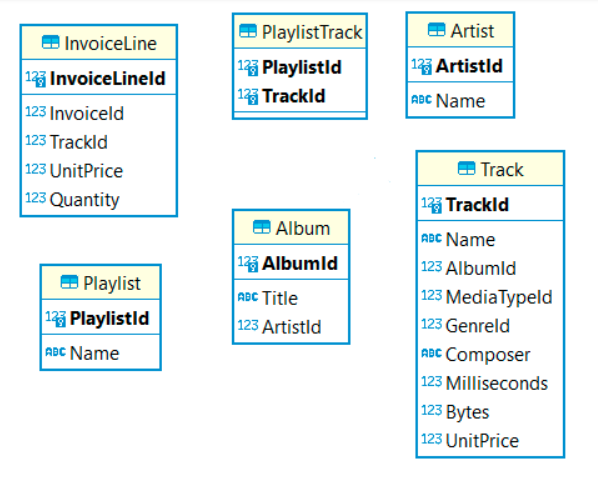

1- Identifer les liens entre les tables, en indiquant à chaque fois le type de la relation (1-N ou N-M).

Quelles clés interviennent pr chaque table , est ce que la clé est primaire ou secondaire ?

\
Exemple de solution attendue :

- Un artiste peut avoir plusieurs albums mais un album est associé obligatoirement à un seul artiste : relation un à plusieurs entre artist(artistId PK) et album (artistId FK)

- Un album peut avoir plusieurs tracks mais un track est associé a un seul album : relation un à plusieurs entre album (AlbumId PK) et Track(AlbumId FK) (ONE TO MANY)

- Un artiste peut avoir plusieurs albums mais un album est associé obligatoirement à un seul artiste : relation un à plusieurs entre artist(artistId PK) et album (artistId FK) (ONE TO MANY)

- Une playlisttrack peut avoir plusieurs tracks et plusieurs tracks peuvent apparaitre dans plusieurs playlisttrack : relation plusieurs a plusieurs entre playlisttrack(TrackId FK) et track(TrackId PK) (MANY TO MANY), idem pour la relation entre trackId et playlisttrack. Playlisttrack est une table intermédiaire entre Playlist et Track

- Une invoiceline a un Track et un track a une invoiceline : relation un a un entre invoiceline (TrackId FK) et Track (TrackId PK) (ONE TO ONE)

- Une playlist peut contenir plusieurs playlistTrack et une playlistTrack appartient a une seule playlist : relation un a plusieurs entre playlist(PlaylistId PK) et playlisttrack(PlaylistId FK)

2- Identifier la relation many to many ? Comment avez vous pu l'identifier ?

La relation Many to Many est entre Playlist et Track, nous l'identifions grace a la table intermédiaire PlaylistTrack

 3-  Quels morceaux de la base de données Chinook ont un compositeur spécifié ?

In [5]:
#ecrire votre requete dans r
r = """
SELECT name, composer
FROM track
WHERE composer is not NULL

"""
df = pd.read_sql(r, conn)

In [6]:
print(df.head().to_markdown()) #ex d'affichage attendu

|    | Name                                    | Composer                                                               |
|---:|:----------------------------------------|:-----------------------------------------------------------------------|
|  0 | For Those About To Rock (We Salute You) | Angus Young, Malcolm Young, Brian Johnson                              |
|  1 | Fast As a Shark                         | F. Baltes, S. Kaufman, U. Dirkscneider & W. Hoffman                    |
|  2 | Restless and Wild                       | F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. Dirkscneider & W. Hoffman |
|  3 | Princess of the Dawn                    | Deaffy & R.A. Smith-Diesel                                             |
|  4 | Put The Finger On You                   | Angus Young, Malcolm Young, Brian Johnson                              |


4- Top 5 des morceaux les plus long et top 5 des morceaux les moins long

In [7]:
# Top 5 plus long
r = """
SELECT name, milliseconds
FROM track
ORDER by milliseconds DESC
LIMIT 5
"""
df = pd.read_sql(r, conn)

In [8]:
print(df) #ex d'affichage attendu

                          Name  Milliseconds
0       Occupation / Precipice       5286953
1      Through a Looking Glass       5088838
2  Greetings from Earth, Pt. 1       2960293
3      The Man With Nine Lives       2956998
4  Battlestar Galactica, Pt. 2       2956081


In [9]:
# Top 5 moins long
r = """
SELECT name, milliseconds
FROM track
ORDER by milliseconds ASC
LIMIT 5
"""
df = pd.read_sql(r, conn)

In [10]:
print(df) #ex d'affichage attendu

                       Name  Milliseconds
0  É Uma Partida De Futebol          1071
1                Now Sports          4884
2               A Statistic          6373
3                     Oprah          6635
4              Commercial 1          7941


5- Afficher les titre  de musique qui dure entre 3 et 6 minutes

In [11]:

r = """
SELECT name, milliseconds
FROM track
WHERE milliseconds BETWEEN 180000 AND 360000

"""
df = pd.read_sql(r, conn)

display(df) #ex d'affichage attendu

,Name,Milliseconds
0,For Those About To Rock (We Salute You),343719
1,Balls to the Wall,342562
2,Fast As a Shark,230619
3,Restless and Wild,252051
4,Put The Finger On You,205662
...,...,...
2395,"24 Caprices, Op. 1, No. 24, for Solo Violin, i...",265541
2396,"Erlkonig, D.328",261849
2397,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,286741
2398,"Quintet for Horn, Violin, 2 Violas, and Cello ...",221331


6- Afficher les morceaux qui appartiennent à une de ces playlist : "Music Videos" , Grunge, "TV Show"

In [12]:

r = """
SELECT track.name, playlist.name
FROM track JOIN playlisttrack ON track.trackid = playlisttrack.trackid
JOIN playlist ON playlisttrack.playlistid = playlist.playlistid
WHERE playlist.name is "Music Videos" OR playlist.name is "Grunge" OR playlist.name is "TV Shows"

"""
df = pd.read_sql(r, conn)
display(df) #ex d'affichage attendu

,Name,Name
0,Pilot,TV Shows
1,Battlestar Galactica: The Story So Far,TV Shows
2,Occupation / Precipice,TV Shows
3,"Exodus, Pt. 1",TV Shows
4,"Exodus, Pt. 2",TV Shows
...,...,...
437,In Bloom,Grunge
438,Come As You Are,Grunge
439,Lithium,Grunge
440,Drain You,Grunge


7- Pouvez-vous fournir une liste des morceaux de l'artiste Aerosmith, avec leurs prix unitaires correspondants?

In [13]:

r = """
SELECT track.name, track.unitprice
FROM track JOIN album ON track.albumid = album.albumid
JOIN artist ON album.artistid = artist.artistid
WHERE artist.name is "Aerosmith"
"""
df = pd.read_sql(r, conn)
display(df) #ex d'affichage attendu

,Name,UnitPrice
0,Walk On Water,0.99
1,Love In An Elevator,0.99
2,Rag Doll,0.99
3,What It Takes,0.99
4,Dude (Looks Like A Lady),0.99
5,Janie's Got A Gun,0.99
6,Cryin',0.99
7,Amazing,0.99
8,Blind Man,0.99
9,Deuces Are Wild,0.99


8- Renvoyer le nombre de morceaux par artiste et par album

In [20]:
r = """
SELECT artist.name, album.title, COUNT(trackid) as nbr_track
FROM album JOIN artist ON album.artistid = artist.artistid
JOIN track ON track.albumid = album.albumid
GROUP BY artist.name, album.title
"""
df = pd.read_sql(r, conn)
display(df) #ex d'affichage attendu

,Name,Title,nbr_track
0,AC/DC,For Those About To Rock We Salute You,10
1,AC/DC,Let There Be Rock,8
2,Aaron Copland & London Symphony Orchestra,"A Copland Celebration, Vol. I",1
3,Aaron Goldberg,Worlds,1
4,Academy of St. Martin in the Fields & Sir Nevi...,The World of Classical Favourites,2
...,...,...,...
342,Vinícius De Moraes,Vinicius De Moraes,15
343,Wilhelm Kempff,Bach: Goldberg Variations,1
344,Yehudi Menuhin,Bartok: Violin & Viola Concertos,1
345,Yo-Yo Ma,Bach: The Cello Suites,1


9- Quelles sont les 3 playlists qui contiennent le plus grand nombre d'artistes différents ? Les playlists ayant le nom égale à "Music" doivent être exclus.

In [24]:
r = """
SELECT playlist.name, COUNT(DISTINCT artist.name) as number_artists
FROM playlist JOIN playlisttrack ON playlist.playlistid = playlisttrack.playlistid
JOIN track ON playlisttrack.trackid = track.trackid
JOIN album ON album.albumid = track.albumid
JOIN artist ON artist.artistid = album.artistid
WHERE playlist.name <> "Music"
GROUP BY playlist.name
ORDER BY number_artists DESC LIMIT 3"""   
df = pd.read_sql(r, conn)
display(df) #ex d'affichage attendu

,Name,number_artists
0,90’s Music,109
1,Classical,67
2,Classical 101 - The Basics,25


10- Quel artiste figure dans le plus grand nombre de playlists différentes ?

In [16]:
r = """
SELECT artist.name, COUNT(DISTINCT playlist.name) as number_playlist
FROM artist
JOIN album ON album.artistid = artist.artistid
JOIN track ON track.albumid = album.albumid
JOIN playlisttrack ON track.trackid = playlisttrack.trackid
JOIN playlist ON playlist.playlistid = playlisttrack.playlistid
GROUP BY artist.name
ORDER BY number_playlist DESC
LIMIT 1
"""
df = pd.read_sql(r, conn)
display(df) #ex d'affichage attendu

,Name,number_playlist
0,Eugene Ormandy,6


11- Calculer la moyenne du prix unitaire des morceaux pour chaque artiste et filtrer les artistes ayant une moyenne de prix supperieur à 1

In [17]:
r = """
SELECT artist.name, AVG(track.unitprice) as AVGprice
FROM track
JOIN album ON track.albumid = album.albumid
JOIN artist ON album.artistid = artist.artistid
GROUP BY artist.name
HAVING AVGprice > 1
ORDER BY artist.name
"""
df = pd.read_sql(r, conn)
display(df) #ex d'affichage attendu

,Name,AVGprice
0,Aquaman,1.99
1,Battlestar Galactica,1.99
2,Battlestar Galactica (Classic),1.99
3,Heroes,1.99
4,Lost,1.99
5,The Office,1.99


12- Afficher les artistes qui n'ont pas d'albums

In [18]:


r = """
SELECT artist.name, album.title
FROM artist
LEFT JOIN album ON album.artistid = artist.artistid
WHERE album.title is NULL
ORDER BY artist.name

"""
df = pd.read_sql(r, conn) #ex d'affichage attendu
display(df)

,Name,Title
0,A Cor Do Som,None
1,"Academy of St. Martin in the Fields, Sir Nevil...",None
2,Aerosmith & Sierra Leone's Refugee Allstars,None
3,Avril Lavigne,None
4,Azymuth,None
...,...,...
66,Vinícius E Odette Lara,None
67,Vinícius E Qurteto Em Cy,None
68,Whitesnake,None
69,Xis,None
